## 왜 NumPy와 Pandas인가?

### Python 기본 vs 데이터 분석 라이브러리

```python
# Python 리스트로 평균 계산 - 5줄
production = [1200, 1150, 1300, 1180, 1250]
total = 0
for x in production:
    total += x
average = total / len(production)

# NumPy로 평균 계산 - 1줄!
import numpy as np
production = np.array([1200, 1150, 1300, 1180, 1250])
average = production.mean()
```

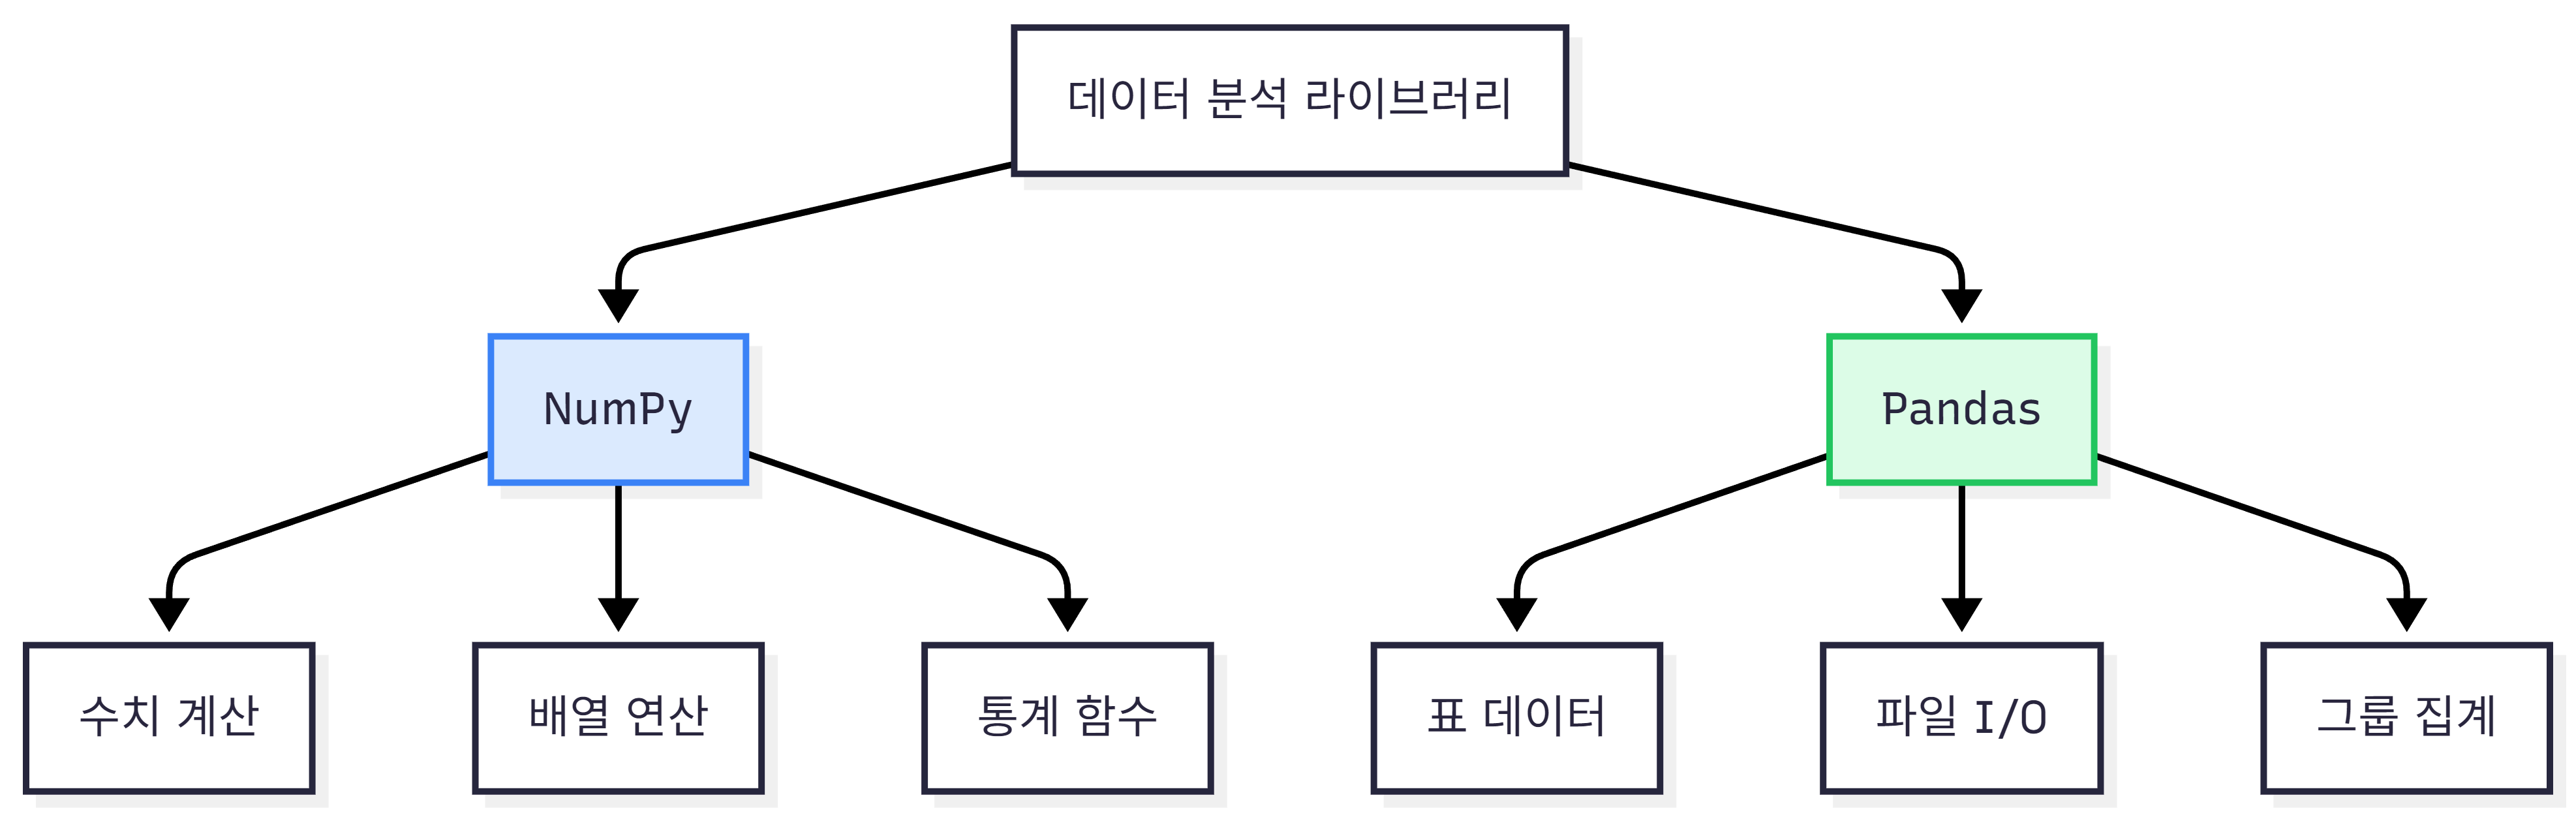

> **속도**: NumPy는 Python 리스트보다 최대 **100배 빠름**

In [19]:
import numpy as np

np_huge_array = np.linspace(1, 10000000, 10000000)
py_huge_array = list(np_huge_array)

print(np_huge_array)

[1.000000e+00 2.000000e+00 3.000000e+00 ... 9.999998e+06 9.999999e+06
 1.000000e+07]


In [23]:
%%time
# Python 리스트로 평균 계산 - 5줄
total = 0
for x in py_huge_array:
    total += x
average = total / len(py_huge_array)

CPU times: total: 922 ms
Wall time: 923 ms


In [24]:
%%time
# NumPy로 평균 계산 - 1줄!
import numpy as np
average = np_huge_array.mean()

CPU times: total: 0 ns
Wall time: 11.2 ms


## NumPy vs Pandas 역할

### 언제 무엇을 사용하나?

| 구분 | NumPy | Pandas |
|------|-------|--------|
| **데이터 형태** | 동일 타입 배열 | 표 형태 (다양한 타입) |
| **주 용도** | 수치 계산, 행렬 연산 | 데이터 분석, 조작 |
| **핵심 객체** | ndarray | DataFrame, Series |
| **제조 예시** | 센서값 계산 | 생산일지 분석 |

> **둘 다 필수!** NumPy → 빠른 계산, Pandas → 데이터 관리

# NumPy 소개

## NumPy = Numerical Python

| 특징 | 설명 |
|------|------|
| **다차원 배열** | ndarray 객체로 행렬 연산 |
| **벡터화 연산** | 반복문 없이 빠른 계산 |
| **브로드캐스팅** | 크기가 다른 배열 간 연산 |
| **통계 함수** | mean, std, max, min 등 내장 |
| **과학 계산** | 선형대수, 푸리에 변환 |

In [25]:
import numpy as np
print(np.__version__)  # 버전 확인

2.4.0


## NumPy 배열 생성

### 다양한 방법으로 배열 만들기

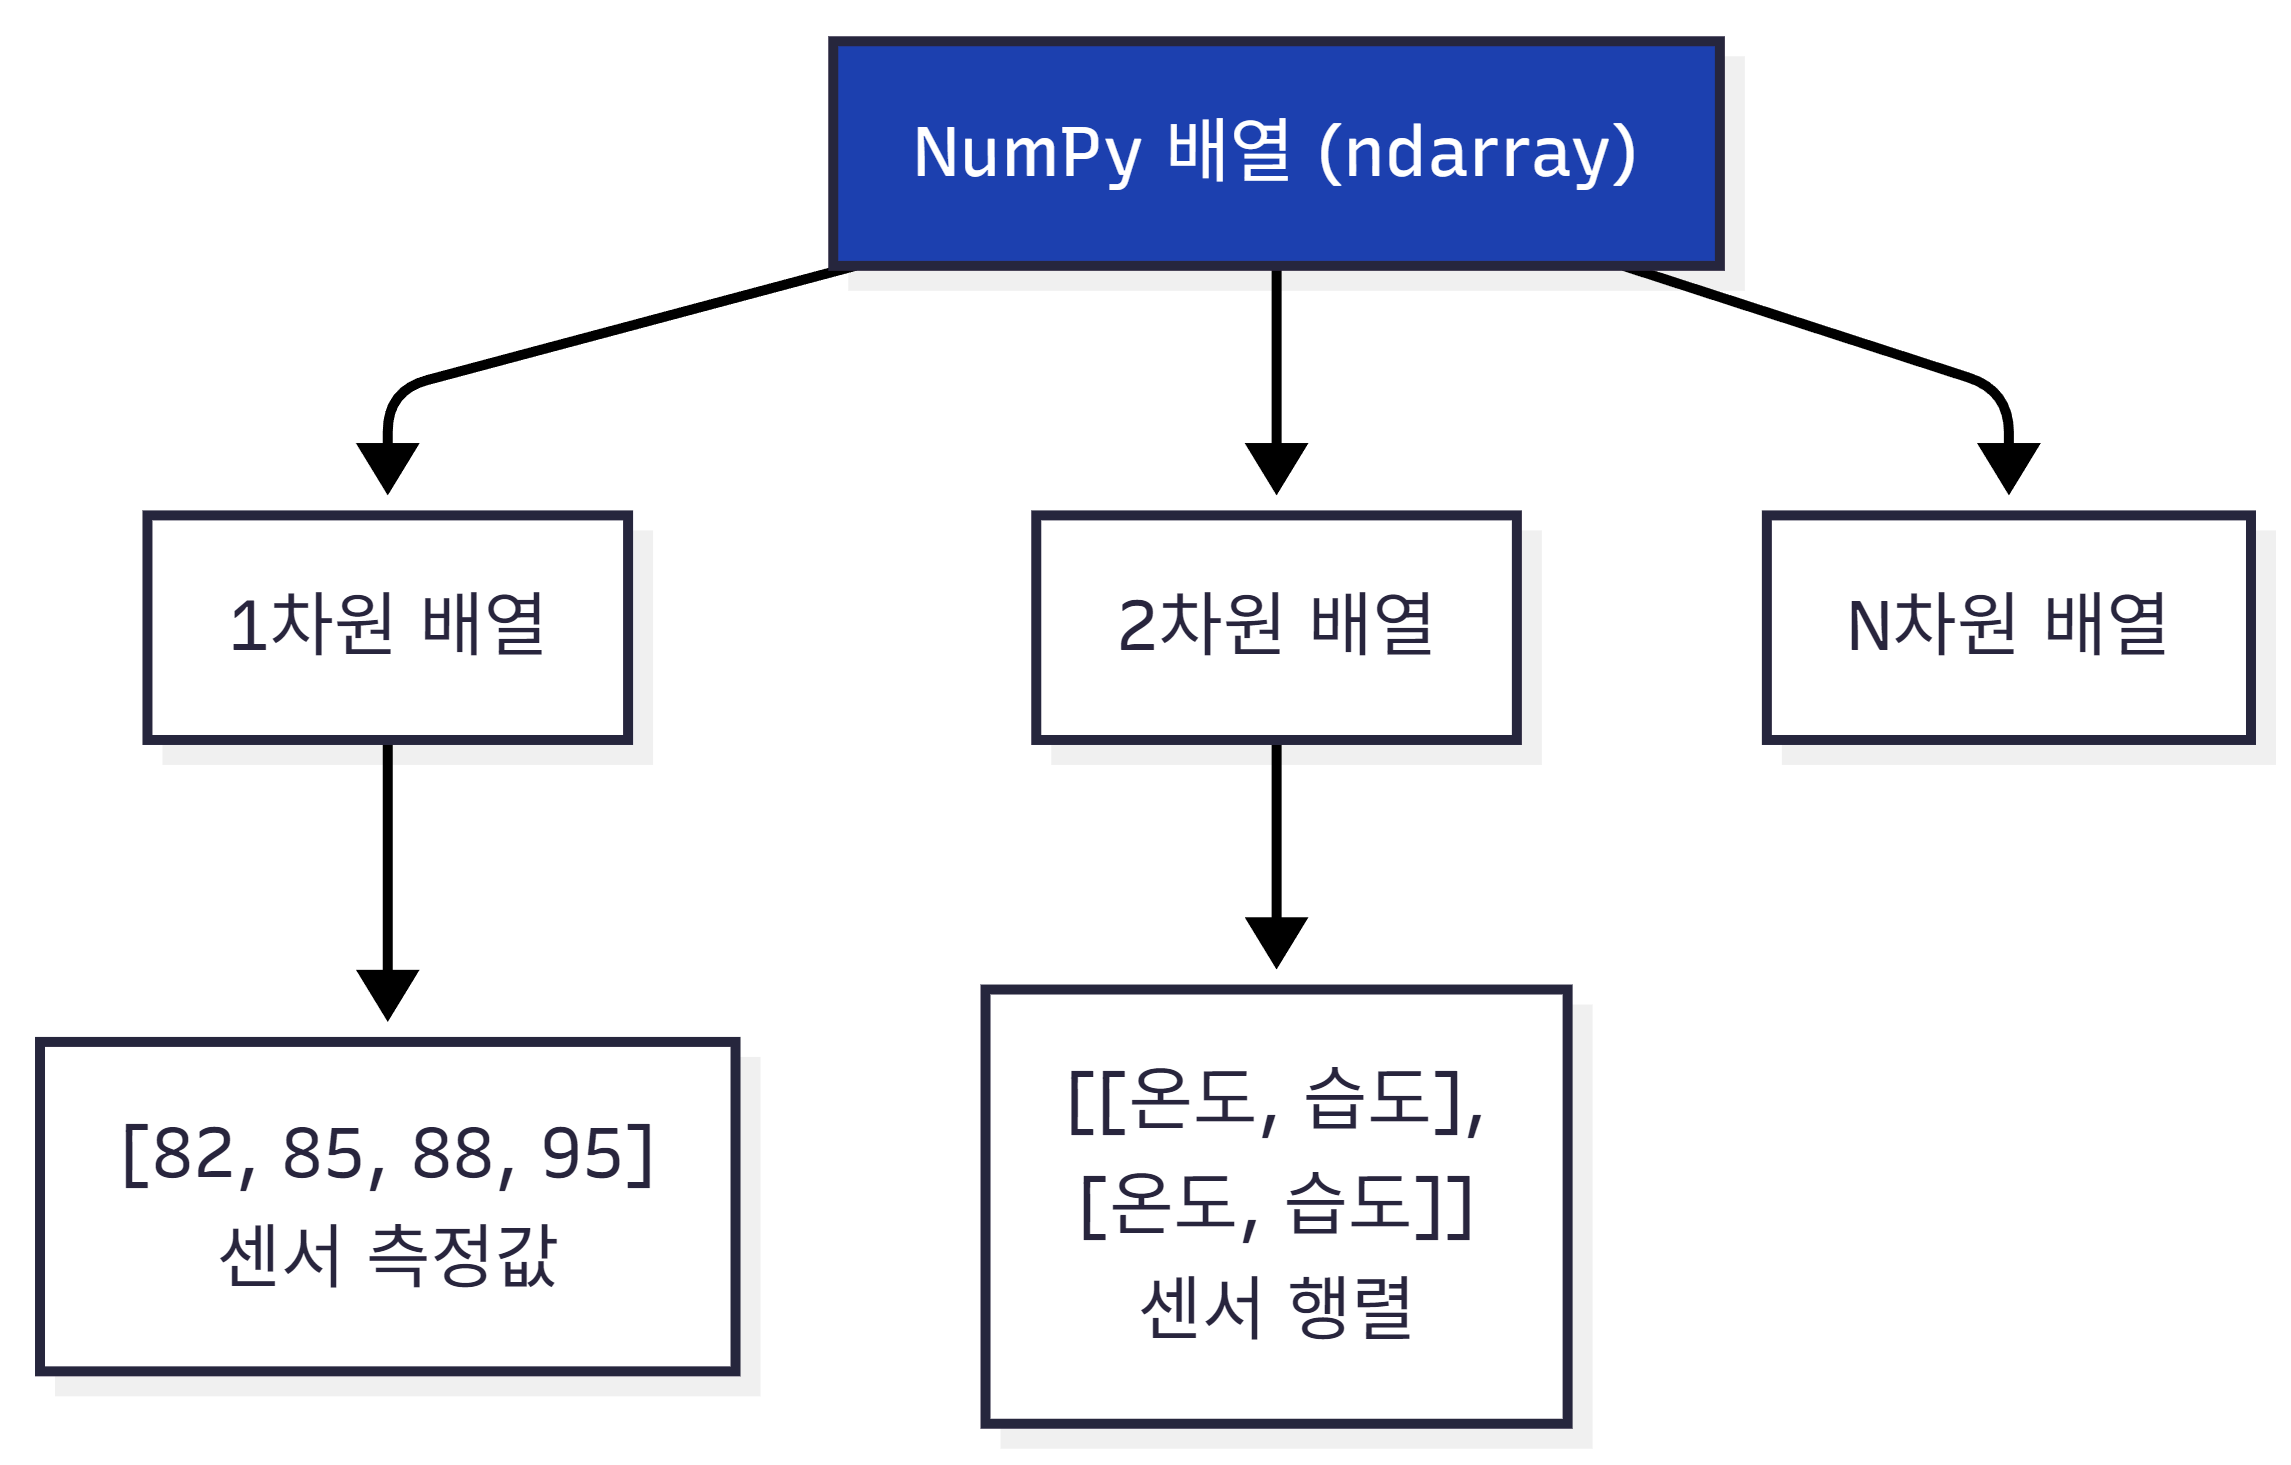

In [26]:
import numpy as np

# 1. 리스트에서 생성
temps = np.array([82, 85, 88, 95, 84])

# 2. 2차원 배열 (행렬)
sensor_matrix = np.array([
    [82, 45, 1.2],  # 온도, 습도, 압력
    [85, 48, 1.1],
    [88, 52, 1.3]
])

# 3. 특수 배열
zeros = np.zeros(5)           # [0, 0, 0, 0, 0]
ones = np.ones(5)             # [1, 1, 1, 1, 1]
range_arr = np.arange(0, 10, 2)  # [0, 2, 4, 6, 8]
linspace = np.linspace(0, 1, 5)  # 균등 간격 5개

## NumPy 배열 속성

### 배열 정보 확인하기

In [28]:
data = np.array([[1, 2, 3], [4, 5, 6]])

print(f"차원: {data.ndim}")        # 2
print(f"형상: {data.shape}")       # (2, 3) - 2행 3열
print(f"크기: {data.size}")        # 6개 요소
print(f"타입: {data.dtype}")       # int64

print(data)

차원: 2
형상: (2, 3)
크기: 6
타입: int64
[[1 2 3]
 [4 5 6]]


## NumPy 인덱싱과 슬라이싱

### 원하는 데이터 접근하기


In [29]:
arr = np.array([10, 20, 30, 40, 50])

# 인덱싱 (0부터 시작)
print(arr[0])     # 10 (첫 번째)
print(arr[-1])    # 50 (마지막)

# 슬라이싱
print(arr[1:4])   # [20, 30, 40]
print(arr[:3])    # [10, 20, 30]
print(arr[2:])    # [30, 40, 50]

# 조건 인덱싱 (불리언 마스크)
print(arr[arr > 25])  # [30, 40, 50]

10
50
[20 30 40]
[10 20 30]
[30 40 50]
[30 40 50]


## NumPy 2차원 배열 접근

### 행/열 선택하기


In [31]:
data = np.array([
    [82, 45, 1.2],   # 0행: 온도, 습도, 압력
    [85, 48, 1.1],   # 1행
    [88, 52, 1.3]    # 2행
])

# 단일 요소
print(data[0, 0])     # 82 (0행 0열)
print(data[1, 2])     # 1.1 (1행 2열)

# 행 선택
print(data[0, :])     # [82, 45, 1.2] (0행 전체)

# 열 선택
print(data[:, 0])     # [82, 85, 88] (온도 열)

82.0
1.1
[82.  45.   1.2]
[82. 85. 88.]


## NumPy 벡터화 연산

### 반복문 없이 빠른 계산

In [33]:
temps = np.array([82, 85, 88, 95, 84])

# 스칼라 연산 (모든 요소에 적용)
print(temps + 10)     # [92, 95, 98, 105, 94]
print(temps * 1.1)    # [90.2, 93.5, ...]
print(temps - 80)     # [2, 5, 8, 15, 4]

# 단위 변환: 섭씨 → 화씨
fahrenheit = temps * 9/5 + 32

# 배열 간 연산
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(a + b)          # [5, 7, 9]
print(a * b)          # [4, 10, 18]

[ 92  95  98 105  94]
[ 90.2  93.5  96.8 104.5  92.4]
[ 2  5  8 15  4]
[5 7 9]
[ 4 10 18]


## NumPy 통계 함수

### 제조 데이터 기본 통계

In [34]:
production = np.array([1200, 1150, 1300, 1180, 1250])

print(f"합계: {np.sum(production)}")        # 6080
print(f"평균: {np.mean(production)}")       # 1216.0
print(f"중앙값: {np.median(production)}")   # 1200.0
print(f"표준편차: {np.std(production):.2f}") # 53.45
print(f"분산: {np.var(production):.2f}")    # 2856.0
print(f"최대값: {np.max(production)}")      # 1300
print(f"최소값: {np.min(production)}")      # 1150
print(f"범위: {np.ptp(production)}")        # 150 (max-min)

합계: 6080
평균: 1216.0
중앙값: 1200.0
표준편차: 53.14
분산: 2824.00
최대값: 1300
최소값: 1150
범위: 150


## NumPy 조건 필터링

### 원하는 데이터만 추출

In [36]:

temps = np.array([82, 85, 88, 95, 84, 91, 86])

# 조건 마스크
mask = temps > 90
print(mask)  # [False, False, False, True, False, True, False]

# 조건에 맞는 값 추출
high_temps = temps[temps > 90]
print(f"90도 초과: {high_temps}")  # [95, 91]
print(f"개수: {len(high_temps)}")  # 2

# 조건 카운트
count = np.sum(temps > 90)  # True = 1로 계산
print(f"90도 초과 횟수: {count}")  # 2

# 조건에 따른 값 변경
adjusted = np.where(temps > 90, temps - 5, temps)
print(adjusted)  # [82, 85, 88, 90, 84, 86, 86]

[False False False  True False  True False]
90도 초과: [95 91]
개수: 2
90도 초과 횟수: 2
[82 85 88 90 84 86 86]


## 실습 1: NumPy 센서 데이터 분석

### 24시간 온도 모니터링

In [37]:
import numpy as np

# 24시간 온도 데이터
temps = np.array([
    82, 84, 85, 87, 88, 90, 92, 95,
    93, 91, 89, 86, 85, 84, 83, 82,
    81, 80, 79, 80, 81, 82, 83, 84
])

print(f"평균 온도: {temps.mean():.1f}도")
print(f"최고 온도: {temps.max()}도 ({temps.argmax()}시)")
print(f"최저 온도: {temps.min()}도 ({temps.argmin()}시)")
print(f"표준편차: {temps.std():.2f}")

# 경고 (90도 초과) 분석
warnings = temps[temps > 90]
print(f"경고 횟수: {len(warnings)}회")
print(f"경고 시간대: {np.where(temps > 90)[0]}시")

평균 온도: 85.2도
최고 온도: 95도 (7시)
최저 온도: 79도 (18시)
표준편차: 4.37
경고 횟수: 4회
경고 시간대: [6 7 8 9]시


# Pandas 소개

## 표 형태 데이터의 표준 도구

| 특징 | 설명 |
|------|------|
| **DataFrame** | Excel처럼 행/열로 구성된 2D 데이터 |
| **Series** | 1차원 데이터 (DataFrame의 한 열) |
| **파일 지원** | CSV, Excel, SQL, JSON 등 |
| **데이터 조작** | 필터링, 정렬, 그룹화, 병합 |
| **통계 분석** | 기술통계, 집계 함수 |

In [38]:
import pandas as pd
print(pd.__version__)  # 버전 확인

ModuleNotFoundError: No module named 'pandas'

In [39]:
!pip install pandas

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------------------------------------- 11.0/11.0 MB 68.3 MB/s  0:00:00

   ---------------------------------------- 0/2 [pytz]
   ---------------------------------------- 0/2 [pytz]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
  

## DataFrame 생성

### 딕셔너리에서 DataFrame 만들기

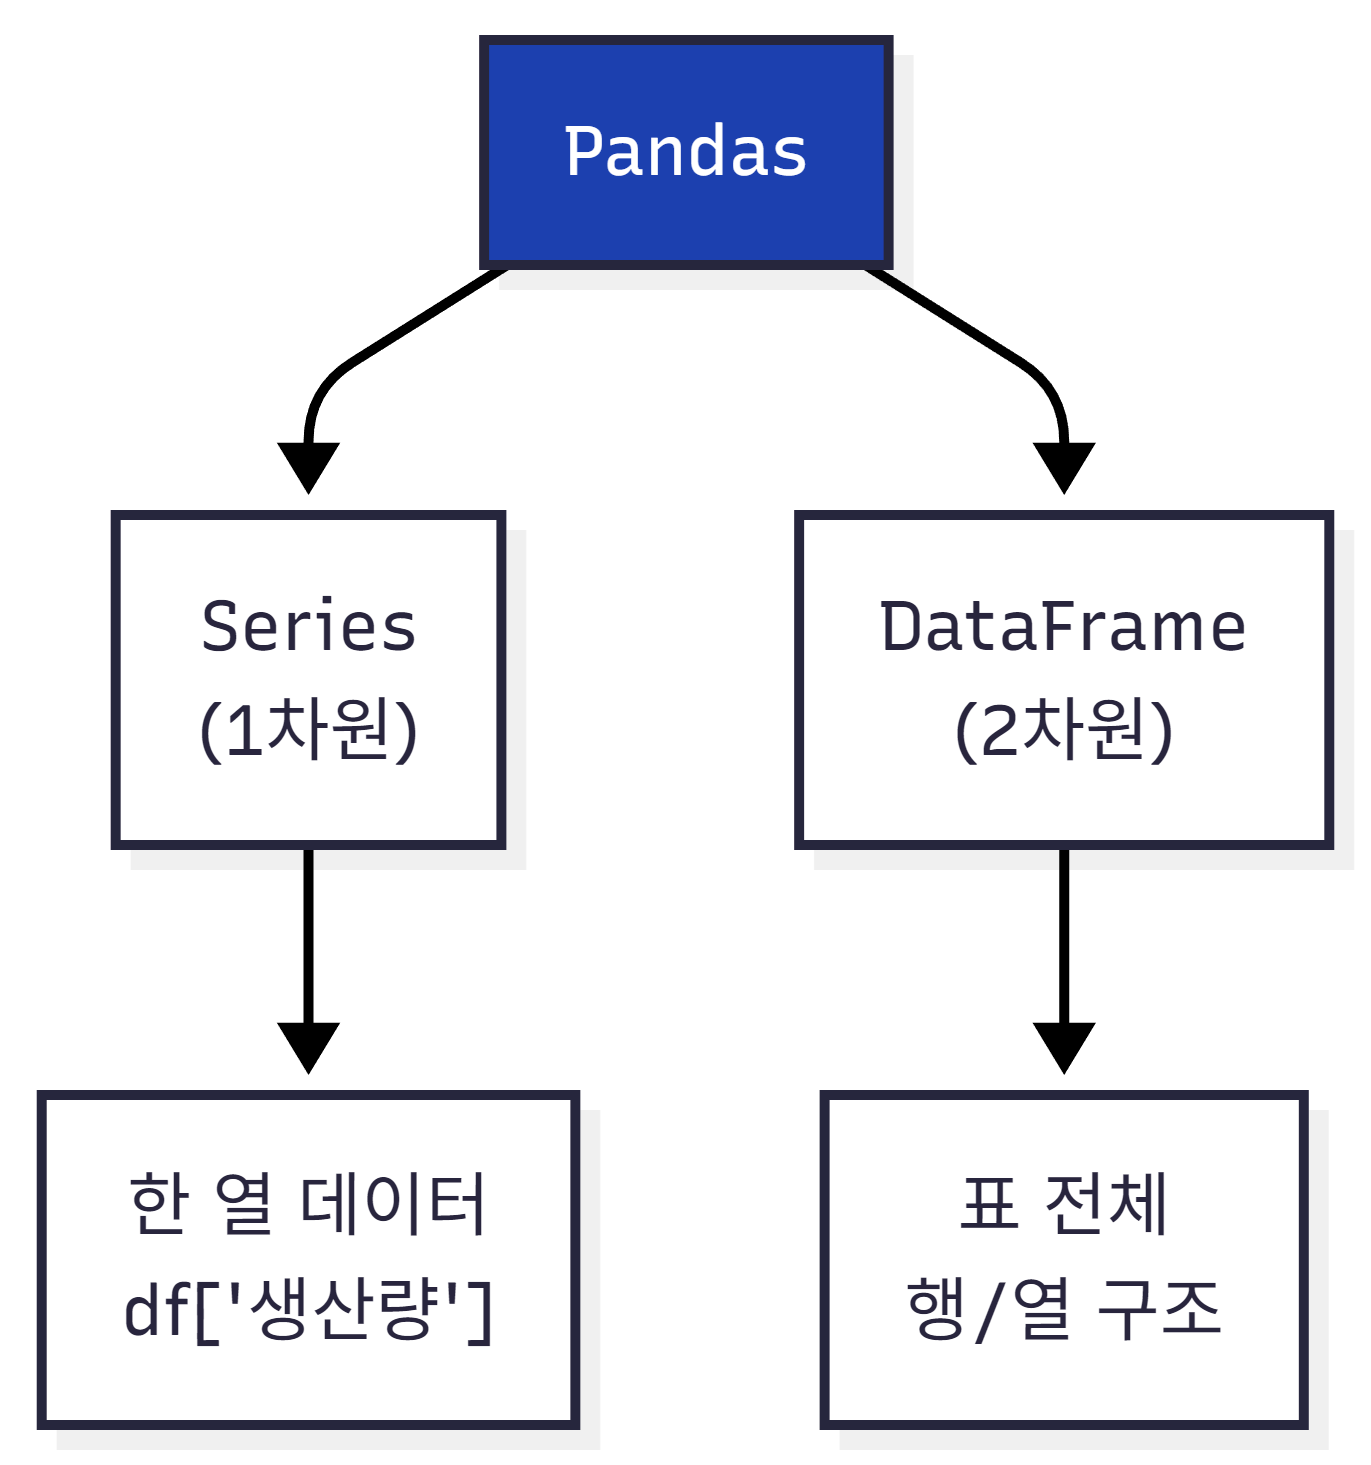

In [40]:
import pandas as pd

data = {
    "제품코드": ["SM-001", "SM-002", "SM-003", "SM-004", "SM-005"],
    "생산량": [1200, 1150, 1300, 1180, 1250],
    "불량수": [24, 35, 26, 42, 25],
    "라인": [1, 2, 1, 2, 1]
}

df = pd.DataFrame(data)
print(df)

     제품코드   생산량  불량수  라인
0  SM-001  1200   24   1
1  SM-002  1150   35   2
2  SM-003  1300   26   1
3  SM-004  1180   42   2
4  SM-005  1250   25   1


## DataFrame 기본 탐색

### 데이터 파악하기

In [61]:
# CSV 파일 읽기
#df = pd.read_csv("production_data.csv", encoding="utf-8")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

# 기본 탐색
df.head()        # 처음 5행
df.tail()        # 마지막 5행
df.shape         # (행수, 열수)
df.columns       # 열 이름 목록
df.dtypes        # 각 열의 데이터 타입
df.info()        # 전체 정보 요약

# 결측치 확인
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [62]:
df.head()        # 처음 5행

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 기본 탐색 습관

In [63]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [64]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [66]:
df.describe(include="all").T  # 문자/숫자 섞여있을 때 전체 요약
df["UDI"].value_counts().head(10)

UDI
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
Name: count, dtype: int64

In [69]:
#이름 변경
rename_map = {
    "UDI": "UID",  # 혹시 UDI로 들어오면 UID로 통일
    "Air temperature [K]": "AirTempK",
    "Process temperature [K]": "ProcTempK",
    "Rotational speed [rpm]": "RotSpeedRpm",
    "Torque [Nm]": "TorqueNm",
    "Tool wear [min]": "ToolWearMin",
    "Product ID": "ProductID",
    "Machine failure": "MachineFailure",
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
df.columns

Index(['UID', 'ProductID', 'Type', 'AirTempK', 'ProcTempK', 'RotSpeedRpm',
       'TorqueNm', 'ToolWearMin', 'MachineFailure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

## DataFrame 열 선택

### 원하는 열만 추출

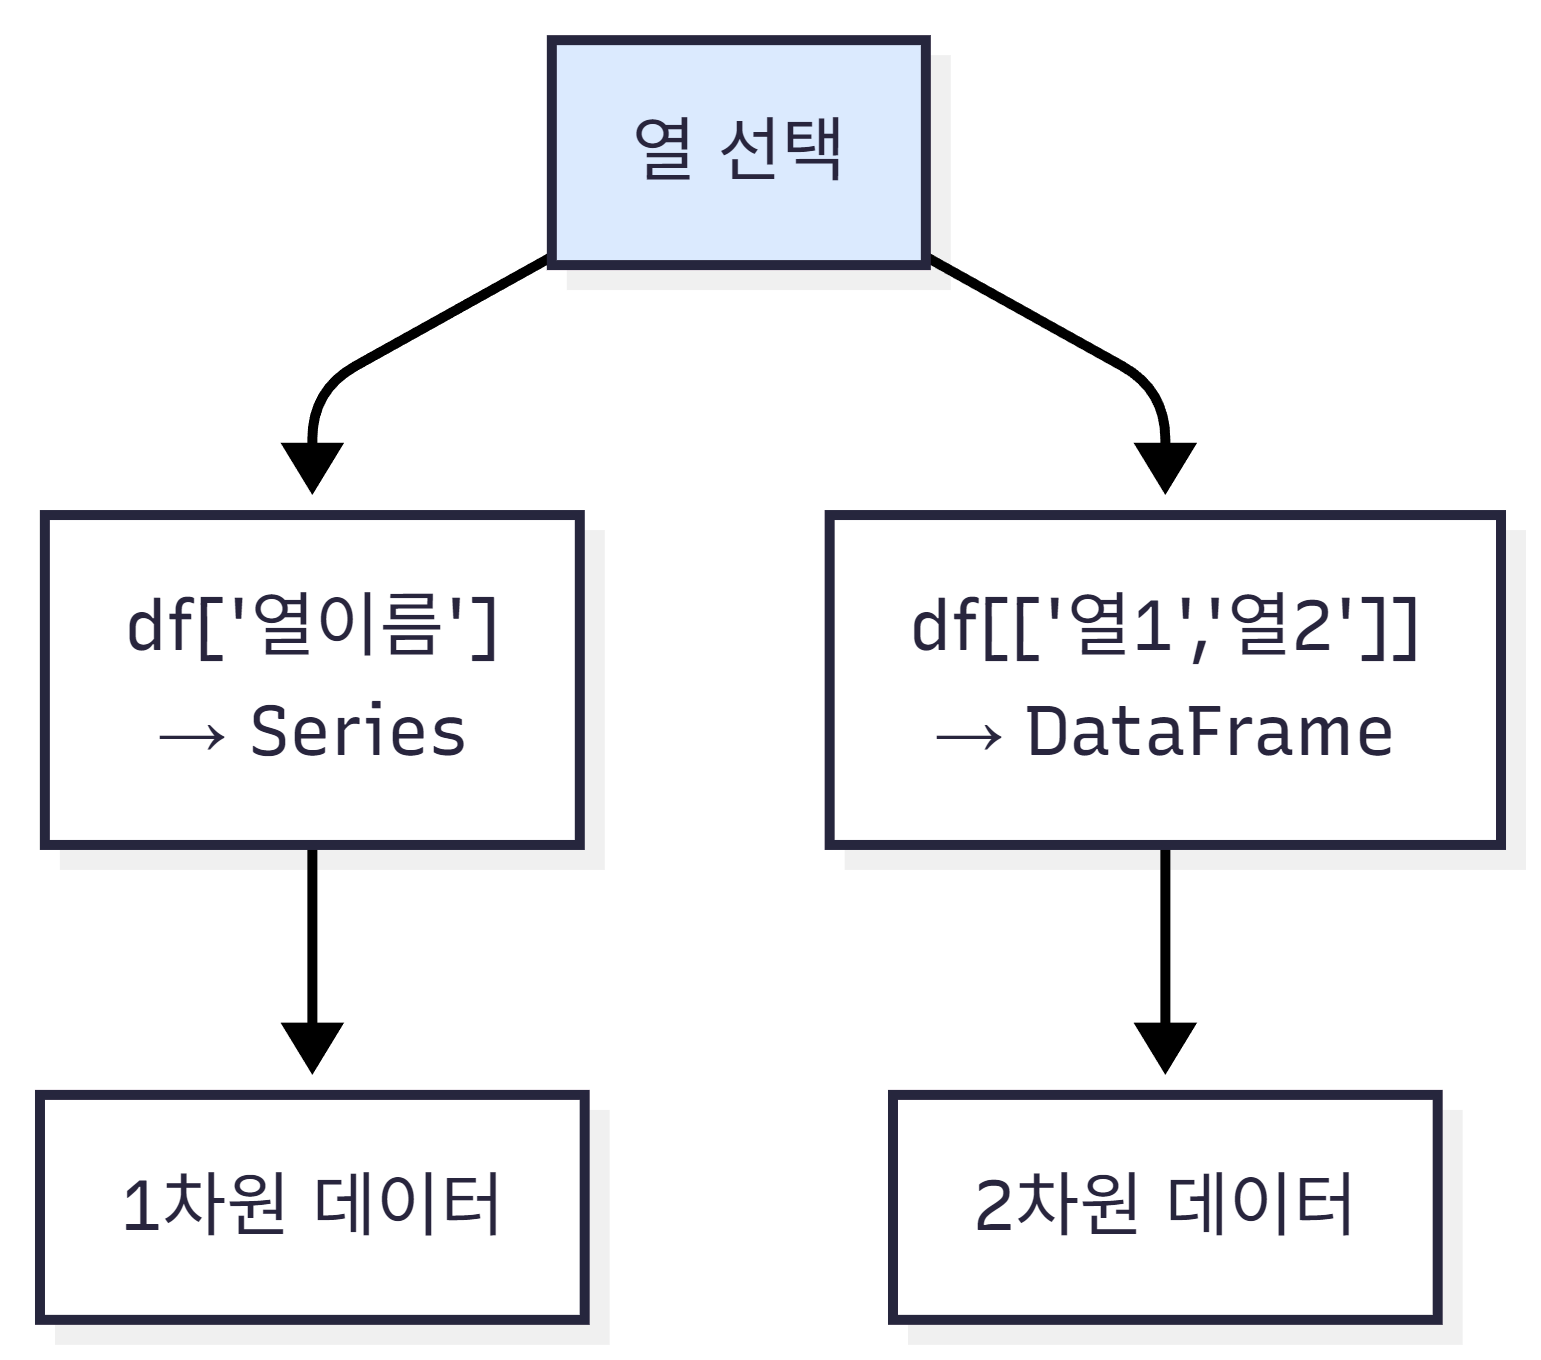

> **주의**: 단일 열은 Series, 다중 열은 DataFrame!


In [72]:
# 단일 열 선택 - Series 반환
rot_speed = df["RotSpeedRpm"]
print(type(rot_speed))  # pandas.Series

# 다중 열 선택 - DataFrame 반환
subset = df[["ProductID", "Type", "RotSpeedRpm", "TorqueNm", "ToolWearMin", "MachineFailure"]]
print(type(subset))  # pandas.DataFrame

sensor_cols = ["AirTempK", "ProcTempK", "RotSpeedRpm", "TorqueNm", "ToolWearMin"]
sensor_df = df[sensor_cols]


# 열 접근 방법 비교
df["RotSpeedRpm"]      # 대괄호 표기 (권장)
df.RotSpeedRpm         # 점 표기 (열 이름에 공백 없을 때)

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


0       1551
1       1408
2       1498
3       1433
4       1408
        ... 
9995    1604
9996    1632
9997    1645
9998    1408
9999    1500
Name: RotSpeedRpm, Length: 10000, dtype: int64

In [73]:
#특정 패턴의 컬럼만 선택(예: 고장 모드 컬럼)
failure_mode_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
failure_mode_cols = [c for c in failure_mode_cols if c in df.columns]  # 안전장치
df[failure_mode_cols].head()


,TWF,HDF,PWF,OSF,RNF
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


## DataFrame 행 선택

### loc과 iloc의 차이

In [75]:
# loc: 라벨 기반 선택 (끝 포함)
df.loc[0]             # 0번 인덱스 행
df.loc[0:2]           # 0, 1, 2번 행 (끝 포함!)
df.loc[0, "TorqueNm"] # 0번 행의 "TorqueNm" 값

# iloc: 정수 인덱스 기반 (끝 미포함)
df.iloc[0]            # 0번 행
df.iloc[0:2]          # 0, 1번 행 (끝 미포함!)
df.iloc[0, 1]         # 0번 행, 1번 열 값

'M14860'

In [76]:
# 샘플링
df.sample(5, random_state=42)

,UID,ProductID,Type,AirTempK,ProcTempK,RotSpeedRpm,TorqueNm,ToolWearMin,MachineFailure,TWF,HDF,PWF,OSF,RNF
6252,6253,L53432,L,300.8,310.3,1538,36.1,198,0,0,0,0,0,0
4684,4685,M19544,M,303.6,311.8,1421,44.8,101,1,0,0,0,0,0
1731,1732,M16591,M,298.3,307.9,1485,42.0,117,0,0,0,0,0,0
4742,4743,L51922,L,303.3,311.3,1592,33.7,14,0,0,0,0,0,0
4521,4522,L51701,L,302.4,310.4,1865,23.9,129,0,0,0,0,0,0


## DataFrame 조건 필터링

### 원하는 데이터만 추출

In [77]:
# 단일 조건
high_prod = df[df["RotSpeedRpm"] > 1500]

# 복합 조건 (AND: &, OR: |)
# 주의: 각 조건을 괄호로 감싸야 함!
filtered = df[(df["TorqueNm"] > 50) & (df["Type"] == "L")]

# OR 조건
type_lm = df[(df["Type"] == "L") | (df["Type"] == "M")]

# isin() 활용
type_lm = df[df["Type"].isin(["L", "M"])]

# 문자열 조건
l_products = df[df["ProductID"].str.startswith("L")]


In [79]:
# 고장 데이터만 보기(가장 기본)
failures = df[df["MachineFailure"] == 1]
failures[["ProductID", "Type", "AirTempK", "ProcTempK", "RotSpeedRpm", "TorqueNm", "ToolWearMin"]].head()

,ProductID,Type,AirTempK,ProcTempK,RotSpeedRpm,TorqueNm,ToolWearMin
50,L47230,L,298.9,309.1,2861,4.6,143
69,L47249,L,298.9,309.0,1410,65.7,191
77,L47257,L,298.8,308.9,1455,41.3,208
160,L47340,L,298.4,308.2,1282,60.7,216
161,L47341,L,298.3,308.1,1412,52.3,218


In [80]:
#“온도차가 작은데 회전속도도 낮은” 케이스(HDF 힌트)
df["TempGapK"] = df["ProcTempK"] - df["AirTempK"]
hdf_like = df[(df["TempGapK"] < 8.6) & (df["RotSpeedRpm"] < 1380)]
hdf_like.head()

,UID,ProductID,Type,AirTempK,ProcTempK,RotSpeedRpm,TorqueNm,ToolWearMin,MachineFailure,TWF,HDF,PWF,OSF,RNF,TempGapK
3236,3237,M18096,M,300.8,309.4,1342,62.4,113,1,0,1,0,0,0,8.6
3760,3761,L50940,L,302.3,310.9,1377,46.8,166,1,0,1,0,0,0,8.6
3787,3788,L50967,L,302.3,310.8,1377,47.3,22,1,0,1,0,0,0,8.5
3793,3794,L50973,L,302.3,310.9,1379,49.3,34,1,0,1,0,0,0,8.6
3806,3807,M18666,M,302.3,310.9,1360,44.0,67,1,0,1,0,0,0,8.6


In [81]:
#between() / query() 활용(가독성↑)
# 토크 30~45 구간
mid_torque = df[df["TorqueNm"].between(30, 45, inclusive="both")]

# query (컬럼명이 정리돼 있을 때 특히 좋음)
q = df.query("TorqueNm > 50 and RotSpeedRpm < 1400 and Type == 'H'")
q.head()

,UID,ProductID,Type,AirTempK,ProcTempK,RotSpeedRpm,TorqueNm,ToolWearMin,MachineFailure,TWF,HDF,PWF,OSF,RNF,TempGapK
18,19,H29432,H,298.8,309.2,1306,54.5,50,0,0,0,0,0,0,10.4
38,39,H29452,H,298.9,309.2,1379,50.7,106,0,0,0,0,0,0,10.3
192,193,H29606,H,298.2,308.4,1398,51.8,76,0,0,0,0,0,0,10.2
212,213,H29626,H,298.4,308.7,1344,52.9,130,0,0,0,0,0,0,10.3
535,536,H29949,H,297.4,309.3,1365,52.4,76,0,0,0,0,0,0,11.9


In [84]:
#결측치가 있다면? notna()와 함께 필터
safe = df[df["TorqueNm"].notna() & (df["TorqueNm"] > 55)]
print(safe)

       UID ProductID Type  AirTempK  ProcTempK  RotSpeedRpm  TorqueNm  \
69      70    L47249    L     298.9      309.0         1410      65.7   
126    127    L47306    L     299.0      308.6         1329      60.5   
137    138    L47317    L     298.7      308.6         1297      55.3   
139    140    L47319    L     298.8      308.6         1268      55.8   
160    161    L47340    L     298.4      308.2         1282      60.7   
...    ...       ...  ...       ...        ...          ...       ...   
9912  9913    L57092    L     298.6      308.9         1327      58.8   
9918  9919    L57098    L     298.4      308.8         1352      56.7   
9919  9920    L57099    L     298.5      308.8         1305      58.7   
9951  9952    L57131    L     298.2      307.8         1355      59.4   
9974  9975    L57154    L     298.6      308.2         1361      68.2   

      ToolWearMin  MachineFailure  TWF  HDF  PWF  OSF  RNF  TempGapK  
69            191               1    0    0    1    

In [85]:
# 복합 논리 + 괄호 실수 방지 팁
# 흔한 실수: df["TorqueNm"] > 50 & df["RotSpeedRpm"] < 1400  (연산자 우선순위 문제)
# 올바른 방식: 각 조건을 괄호로 감싼다
ok = df[(df["TorqueNm"] > 50) & (df["RotSpeedRpm"] < 1400)]

## DataFrame 새 열 추가
### 파생 변수 만들기

In [88]:
# 불량률 계산  (AI4I에서는 '고장 여부'가 0/1 이므로, 행 단위 "고장"을 지표로 설ㅈㅇ)
df["고장여부"] = df["MachineFailure"]

# 퍼센트로 표시(행 단위는 0 또는 100이므로, 보통은 그룹 평균으로 "고장률(%)"을 확인)
df["고장여부_%"] = (df["고장여부"] * 100).round(2)

# 양품수 계산(행 단위 개념으로는 '정상여부'가 더 자연스러움)
df["정상여부"] = 1 - df["고장여부"]

# 조건에 따른 등급 분류 (리스크 등급 예시: 토크/회전속도/마모를 기반으로 임의 기준)
def classify(rate):
    if rate <= 0.02:
        return "A"
    elif rate <= 0.03:
        return "B"
    else:
        return "C"

In [89]:
df

,UID,ProductID,Type,AirTempK,ProcTempK,RotSpeedRpm,TorqueNm,ToolWearMin,MachineFailure,TWF,HDF,PWF,OSF,RNF,TempGapK,고장여부,고장여부_%,정상여부,RiskScore,등급
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,0,0,1,0.340442,C
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,0,0,1,0.376141,C
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,0,0,1,0.381871,C
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,0,0,1,0.348933,C
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,0,0,1,0.356631,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,9.6,0,0,1,0.294889,C
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,9.5,0,0,1,0.305616,C
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,9.6,0,0,1,0.317665,C
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,9.7,0,0,1,0.414700,C


In [90]:
# AI4I에서는 "고장확률"을 바로 알 수 없으므로,
# (예시) 간단한 위험점수(RiskScore)를 만든 뒤 0~1로 정규화해 'rate'처럼 사용
df["TempGapK"] = df["ProcTempK"] - df["AirTempK"]
df["RiskScore"] = (
    (df["ToolWearMin"] / df["ToolWearMin"].max())
    + (df["TorqueNm"] / df["TorqueNm"].max())
    + ((df["RotSpeedRpm"].max() - df["RotSpeedRpm"]) / df["RotSpeedRpm"].max())
) / 3

df["등급"] = df["RiskScore"].apply(classify)

In [91]:
df

,UID,ProductID,Type,AirTempK,ProcTempK,RotSpeedRpm,TorqueNm,ToolWearMin,MachineFailure,TWF,HDF,PWF,OSF,RNF,TempGapK,고장여부,고장여부_%,정상여부,RiskScore,등급
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,0,0,1,0.340442,C
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,0,0,1,0.376141,C
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,0,0,1,0.381871,C
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,0,0,1,0.348933,C
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,0,0,1,0.356631,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,9.6,0,0,1,0.294889,C
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,9.5,0,0,1,0.305616,C
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,9.6,0,0,1,0.317665,C
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,9.7,0,0,1,0.414700,C


## DataFrame 그룹별 집계
### groupby로 그룹 분석

In [92]:
# 라인별 평균 생산량  (AI4I에서는 Type별 평균 회전속도 예시)
df.groupby("Type")["RotSpeedRpm"].mean()

# 라인별 여러 통계 (Type별 여러 통계)
df.groupby("Type").agg({
    "RotSpeedRpm": ["count", "mean", "sum"],
    "ToolWearMin": ["mean", "sum"],
    "RiskScore": "mean"
})

# 등급별 집계 (등급별 평균 리스크/고장여부)
df.groupby("등급")[["RiskScore", "MachineFailure"]].mean()

# 복수 그룹 (Type, 등급별 평균 회전속도)
df.groupby(["Type", "등급"])["RotSpeedRpm"].mean()


Type  등급
H     C     1538.147557
L     C     1539.469167
M     C     1537.598932
Name: RotSpeedRpm, dtype: float64

### “Type별 고장률(%)”은 이렇게 본다

In [93]:
type_fail_rate = df.groupby("Type")["MachineFailure"].mean().mul(100).round(2)
type_fail_rate


Type
H    2.09
L    3.92
M    2.77
Name: MachineFailure, dtype: float64

### 고장 모드별 빈도(열 합)

In [94]:
failure_mode_cols = [c for c in ["TWF", "HDF", "PWF", "OSF", "RNF"] if c in df.columns]
df[failure_mode_cols].sum().sort_values(ascending=False)


HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

## DataFrame 정렬
### sort_values로 정렬하기

In [95]:
# 단일 열 오름차순
df.sort_values("RotSpeedRpm")

# 단일 열 내림차순
df.sort_values("RotSpeedRpm", ascending=False)

# 다중 열 정렬 (Type 오름차순, Torque 내림차순)
df.sort_values(["Type", "TorqueNm"], ascending=[True, False])

# 인덱스 정렬
df.sort_index()

# 상위 N개 추출
df.nlargest(3, "RotSpeedRpm")   # 회전속도 상위 3개
df.nsmallest(3, "RiskScore")    # 리스크 점수 하위 3개


,UID,ProductID,Type,AirTempK,ProcTempK,RotSpeedRpm,TorqueNm,ToolWearMin,MachineFailure,TWF,HDF,PWF,OSF,RNF,TempGapK,고장여부,고장여부_%,정상여부,RiskScore,등급
3867,3868,M18727,M,302.7,311.6,2709,9.7,2,1,0,0,1,0,0,8.9,1,100,0,0.065289,C
3369,3370,L50549,L,301.5,310.9,2760,8.0,15,1,0,0,1,0,0,9.4,1,100,0,0.069129,C
1095,1096,L48275,L,296.9,307.5,2721,9.3,18,1,0,0,1,0,0,10.6,1,100,0,0.083243,C


## 결측치 처리
### 누락된 데이터 다루기

In [97]:
# 결측치 확인
df.isnull().sum()              # 열별 결측치 개수
df.isnull().any()              # 결측치 있는 열
df[df.isnull().any(axis=1)]    # 결측치 있는 행

# 결측치 제거
df.dropna()                    # 결측치 있는 행 제거
df.dropna(subset=["TorqueNm"]) # 특정 열 기준

# 결측치 채우기
df.fillna(0)                   # 0으로 채우기
df.fillna(df.mean(numeric_only=True))  # 평균으로 채우기(숫자열만)
df["TorqueNm"].fillna(df["TorqueNm"].median())  # 중앙값


0       42.8
1       46.3
2       49.4
3       39.5
4       40.0
        ... 
9995    29.5
9996    31.8
9997    33.4
9998    48.5
9999    40.2
Name: TorqueNm, Length: 10000, dtype: float64

In [111]:
df_practice = df.copy()
df_practice.loc[df_practice.sample(10, random_state=0).index, "TorqueNm"] = np.nan

In [112]:
df_practice

,UID,ProductID,Type,AirTempK,ProcTempK,RotSpeedRpm,TorqueNm,ToolWearMin,MachineFailure,TWF,HDF,PWF,OSF,RNF,TempGapK,고장여부,고장여부_%,정상여부,RiskScore,등급
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,0,0,1,0.340442,C
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,0,0,1,0.376141,C
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,0,0,1,0.381871,C
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,0,0,1,0.348933,C
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,0,0,1,0.356631,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,9.6,0,0,1,0.294889,C
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,9.5,0,0,1,0.305616,C
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,9.6,0,0,1,0.317665,C
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,9.7,0,0,1,0.414700,C


In [113]:
df_practice["TorqueNm"]

0       42.8
1       46.3
2       49.4
3       39.5
4       40.0
        ... 
9995    29.5
9996    31.8
9997    33.4
9998    48.5
9999    40.2
Name: TorqueNm, Length: 10000, dtype: float64

In [114]:
print(df_practice["TorqueNm"].isna().sum())

df_practice[df_practice["TorqueNm"].isna()]


10


,UID,ProductID,Type,AirTempK,ProcTempK,RotSpeedRpm,TorqueNm,ToolWearMin,MachineFailure,TWF,HDF,PWF,OSF,RNF,TempGapK,고장여부,고장여부_%,정상여부,RiskScore,등급
898,899,L48078,L,295.6,306.2,1446,NaN,133,0,0,0,0,0,0,10.6,0,0,1,0.558696,C
2343,2344,L49523,L,299.1,308.3,1305,NaN,17,0,0,0,0,0,0,9.2,0,0,1,0.472192,C
2398,2399,L49578,L,299.2,308.5,1490,NaN,158,0,0,0,0,0,0,9.3,0,0,1,0.557396,C
2670,2671,L49850,L,299.8,309.4,1467,NaN,219,0,0,0,0,0,0,9.6,0,0,1,0.653477,C
3497,3498,L50677,L,301.9,311.0,1642,NaN,126,0,0,0,0,0,0,9.1,0,0,1,0.453728,C
5506,5507,L52686,L,302.9,312.2,1677,NaN,46,0,0,0,0,0,0,9.3,0,0,1,0.332970,C
5906,5907,L53086,L,300.7,310.3,1533,NaN,198,0,0,0,0,0,0,9.6,0,0,1,0.572059,C
6451,6452,L53631,L,300.7,310.2,1696,NaN,73,0,0,0,0,0,0,9.5,0,0,1,0.353294,C
8225,8226,L55405,L,299.1,310.5,1532,NaN,62,0,0,0,0,0,0,11.4,0,0,1,0.397343,C
9394,9395,L56574,L,297.7,308.2,1334,NaN,156,0,0,0,0,0,0,10.5,0,0,1,0.615425,C


In [106]:
df_practice["TorqueNm"] = df_practice["TorqueNm"].fillna(df_practice["TorqueNm"].median())

## CSV 파일 읽기/쓰기
### 가장 많이 사용하는 기능

In [115]:
# CSV 읽기
df = pd.read_csv("data.csv")
df = pd.read_csv("data.csv", encoding="utf-8")
df = pd.read_csv("data.csv", encoding="cp949")  # 한글

# 옵션
df = pd.read_csv("data.csv",
    header=0,              # 첫 번째 행이 헤더
    index_col="날짜",      # 인덱스 열 지정
    parse_dates=["날짜"],  # 날짜 파싱
    na_values=["NA", ""]   # 결측치로 인식할 값
)

# CSV 저장
df.to_csv("output.csv", index=False, encoding="utf-8")

FileNotFoundError: [Errno 2] No such file or directory: 'data.csv'

## 실습 2: DataFrame 생성 및 탐색
### 일주일 생산 데이터

In [116]:
import pandas as pd
import numpy as np

# 1) 데이터 로드
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

# 2) 컬럼명 정리
df = df.rename(columns={
    "Air temperature [K]": "AirTempK",
    "Process temperature [K]": "ProcTempK",
    "Rotational speed [rpm]": "RotSpeedRpm",
    "Torque [Nm]": "TorqueNm",
    "Tool wear [min]": "ToolWearMin",
    "Product ID": "ProductID",
    "Machine failure": "MachineFailure",
    "UDI": "UID"
})

# 3) 7개 샘플 + 날짜 붙이기(실습용)
week = df.sample(7, random_state=42).copy()
week["날짜"] = pd.date_range("2024-12-09", periods=7)  # 임의 날짜

print(week)
print(f"\n데이터 크기: {week.shape}")
print(f"\n기본 통계:\n{week[['AirTempK','ProcTempK','RotSpeedRpm','TorqueNm','ToolWearMin','MachineFailure']].describe()}")


       UID ProductID Type  AirTempK  ProcTempK  RotSpeedRpm  TorqueNm  \
6252  6253    L53432    L     300.8      310.3         1538      36.1   
4684  4685    M19544    M     303.6      311.8         1421      44.8   
1731  1732    M16591    M     298.3      307.9         1485      42.0   
4742  4743    L51922    L     303.3      311.3         1592      33.7   
4521  4522    L51701    L     302.4      310.4         1865      23.9   
6340  6341    H35754    H     300.5      309.9         1397      45.9   
576    577    H29990    H     297.7      309.7         1440      51.1   

      ToolWearMin  MachineFailure  TWF  HDF  PWF  OSF  RNF         날짜  
6252          198               0    0    0    0    0    0 2024-12-09  
4684          101               1    0    0    0    0    0 2024-12-10  
1731          117               0    0    0    0    0    0 2024-12-11  
4742           14               0    0    0    0    0    0 2024-12-12  
4521          129               0    0    0    0    0  

## 실습 3: 불량률 계산
### 파생 변수 추가

In [117]:
# 고장여부(0/1)
week["고장여부"] = week["MachineFailure"]
week["고장여부_%"] = (week["고장여부"] * 100).round(2)

# 온도차
week["TempGapK"] = week["ProcTempK"] - week["AirTempK"]

# 파워 근사(P = Torque * omega), omega = rpm * 2π / 60
week["OmegaRadPerSec"] = week["RotSpeedRpm"] * 2 * np.pi / 60
week["PowerW"] = week["TorqueNm"] * week["OmegaRadPerSec"]

# 간단 위험점수(0~1 스케일)
week["RiskScore"] = (
    (week["ToolWearMin"] / week["ToolWearMin"].max())
    + (week["TorqueNm"] / week["TorqueNm"].max())
    + ((week["RotSpeedRpm"].max() - week["RotSpeedRpm"]) / week["RotSpeedRpm"].max())
) / 3

# 등급 분류(원본 로직 유지: A/B/C)
week["등급"] = week["RiskScore"].apply(
    lambda x: "A" if x <= 0.02 else ("B" if x <= 0.03 else "C")
)

print(week[["날짜", "ProductID", "Type", "RotSpeedRpm", "TorqueNm", "ToolWearMin", "TempGapK", "PowerW", "고장여부_%", "등급"]])


             날짜 ProductID Type  RotSpeedRpm  TorqueNm  ToolWearMin  TempGapK  \
6252 2024-12-09    L53432    L         1538      36.1          198       9.5   
4684 2024-12-10    M19544    M         1421      44.8          101       8.2   
1731 2024-12-11    M16591    M         1485      42.0          117       9.6   
4742 2024-12-12    L51922    L         1592      33.7           14       8.0   
4521 2024-12-13    L51701    L         1865      23.9          129       8.0   
6340 2024-12-14    H35754    H         1397      45.9          210       9.4   
576  2024-12-15    H29990    H         1440      51.1          191      12.0   

           PowerW  고장여부_% 등급  
6252  5814.229300       0  C  
4684  6666.543387     100  C  
1731  6531.371127       0  C  
4742  5618.256750       0  C  
4521  4667.726005       0  C  
6340  6714.871554     100  C  
576   7705.698461       0  C  


In [118]:
## 실습 4: 조건 필터링
### 원하는 데이터만 추출

In [120]:
# 고장여부 1(고장 발생)
high_defect = week[week["MachineFailure"] == 1]
print("=== 고장 발생(1) ===")
print(high_defect[["날짜", "ProductID", "Type", "MachineFailure"]])

# L 타입(Type == 'L') 데이터
line1 = week[week["Type"] == "L"]
print("\n=== Type == 'L' ===")
print(line1[["날짜", "RotSpeedRpm", "TorqueNm", "ToolWearMin", "고장여부_%"]])

# 복합 조건: A등급 AND 토크 45 이상(예시)
excellent = week[(week["등급"] == "A") & (week["TorqueNm"] >= 45)]
print("\n=== A등급 & Torque 45+ ===")
print(excellent)

# (사례1) 온도차가 매우 작은데 회전속도도 낮은 케이스(HDF 힌트)
hdf_like = week[(week["TempGapK"] < 8.6) & (week["RotSpeedRpm"] < 1380)]

# (사례2) ProductID가 L로 시작하는 제품만
l_products = week[week["ProductID"].str.startswith("L")]

# (사례3) Type이 L 또는 M
lm = week[week["Type"].isin(["L", "M"])]

print("\n=== HDF-like ===")
print(hdf_like[["날짜", "TempGapK", "RotSpeedRpm", "Type"]])



=== 고장 발생(1) ===
             날짜 ProductID Type  MachineFailure
4684 2024-12-10    M19544    M               1
6340 2024-12-14    H35754    H               1

=== Type == 'L' ===
             날짜  RotSpeedRpm  TorqueNm  ToolWearMin  고장여부_%
6252 2024-12-09         1538      36.1          198       0
4742 2024-12-12         1592      33.7           14       0
4521 2024-12-13         1865      23.9          129       0

=== A등급 & Torque 45+ ===
Empty DataFrame
Columns: [UID, ProductID, Type, AirTempK, ProcTempK, RotSpeedRpm, TorqueNm, ToolWearMin, MachineFailure, TWF, HDF, PWF, OSF, RNF, 날짜, 고장여부, 고장여부_%, TempGapK, OmegaRadPerSec, PowerW, RiskScore, 등급]
Index: []

[0 rows x 22 columns]

=== HDF-like ===
Empty DataFrame
Columns: [날짜, TempGapK, RotSpeedRpm, Type]
Index: []


## 그룹별 집계
### 라인별 성과 분석

In [121]:
# Type별 평균(원본 구조 유지)
line_stats = week.groupby("Type").agg({
    "RotSpeedRpm": ["count", "mean", "sum"],
    "ToolWearMin": "sum",
    "RiskScore": "mean",
    "MachineFailure": "mean"
}).round(3)

print("=== Type별 통계 ===")
print(line_stats)

# 등급별 분포
print("\n=== 등급별 건수 ===")
print(week["등급"].value_counts())

# 최우수/개선 필요 Type (고장률이 낮을수록 우수)
best = week.groupby("Type")["MachineFailure"].mean().idxmin()
worst = week.groupby("Type")["MachineFailure"].mean().idxmax()
print(f"\n최우수 Type: {best}")
print(f"개선 필요: {worst}")


=== Type별 통계 ===
     RotSpeedRpm               ToolWearMin RiskScore MachineFailure
           count    mean   sum         sum      mean           mean
Type                                                               
H              2  1418.5  2837         401     0.714            0.5
L              3  1665.0  4995         341     0.420            0.0
M              2  1453.0  2906         218     0.530            0.5

=== 등급별 건수 ===
등급
C    7
Name: count, dtype: int64

최우수 Type: L
개선 필요: H


In [122]:
print("=" * 50)
print("      AI4I 주간(샘플) 예지보전 리포트")
print("=" * 50)
print(f"분석 기간: {week['날짜'].min().date()} ~ {week['날짜'].max().date()}")
print("-" * 50)
print(f"샘플 수: {len(week):,}건")
print(f"고장 건수: {week['MachineFailure'].sum():,}건")
print(f"고장률: {week['MachineFailure'].mean()*100:.2f}%")
print(f"평균 위험점수: {week['RiskScore'].mean():.3f}")
print("-" * 50)
print("Type별 고장률:")
for t in week["Type"].unique():
    t_data = week[week["Type"] == t]
    rate = t_data["MachineFailure"].mean() * 100
    print(f"  Type {t}: {rate:.2f}%")
print("-" * 50)
print(f"A등급: {(week['등급']=='A').sum()}건")
print(f"B등급: {(week['등급']=='B').sum()}건")
print(f"C등급: {(week['등급']=='C').sum()}건")
print("=" * 50)


      AI4I 주간(샘플) 예지보전 리포트
분석 기간: 2024-12-09 ~ 2024-12-15
--------------------------------------------------
샘플 수: 7건
고장 건수: 2건
고장률: 28.57%
평균 위험점수: 0.535
--------------------------------------------------
Type별 고장률:
  Type L: 0.00%
  Type M: 50.00%
  Type H: 50.00%
--------------------------------------------------
A등급: 0건
B등급: 0건
C등급: 7건


# 이론 정리

## 핵심 포인트

### NumPy
- **배열(ndarray)**: 빠른 수치 계산
- **벡터화 연산**: 반복문 없이 한 번에 계산
- **통계 함수**: mean, std, max, min, sum
- **조건 필터링**: arr[arr > 값]

### Pandas
- **DataFrame**: 표 형태 데이터
- **CSV 읽기/쓰기**: read_csv, to_csv
- **데이터 탐색**: head, info, describe
- **필터링/집계**: 조건 선택, groupby